# Two-Tower Movie Recommender — Full Pipeline

This notebook takes the model architecture and data from your project and walks through
the **entire pipeline end to end**: data loading, exploratory analysis, preprocessing,
model training, evaluation, embedding visualization, and interactive recommendations.

**No `model.pth` was provided**, so this notebook trains one from scratch on your MovieLens
data (`Data/movies.csv`, `Data/ratings.csv`) and saves it — along with the `.pkl` mapping
files — in exactly the format your `Main.py` FastAPI app expects to load.

> ⚠️ **Dataset size note:** this is the full `ml-32m` dataset (32M ratings, ~87.5k movies).
> Training on the *entire* thing on CPU will be very slow. A `SAMPLE_FRACTION` knob is
> provided in the config cell below — start small (e.g. `0.05`) to make sure everything
> runs, then increase it (or switch to a GPU / Colab) for a stronger final model.

**Sections:**
1. Setup & Config
2. Load Data
3. Exploratory Data Analysis (plots)
4. Preprocessing (IDs, genres, train/val split)
5. Dataset & Model definition
6. Training (with loss curve plots)
7. Evaluation (predicted vs actual, residuals, RMSE/MAE)
8. Embedding visualization (PCA of movie/genre embeddings)
9. Save artifacts (`model.pth`, `user_to_index.pkl`, `movie_to_index.pkl`, `movie_genre_map.pkl`) — matches `Main.py`
10. Recommendation function (same logic as `Main.py`)
11. **Interactive cell** — type a user ID and get movie suggestions
12. Bonus: "movies like this one" — type a movie title and get similar movies


## 1. Setup & Config

In [ ]:
import os
import pickle
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)


In [ ]:
class Config:
    # --- paths (adjust if your Data folder lives elsewhere) ---
    MOVIES_PATH = "/kaggle/input/datasets/daksh59678/movies/movies.csv"
    RATINGS_PATH = "/kaggle/input/datasets/daksh59678/movies/ratings.csv"

    # --- data sampling (ml-32m is huge; start small, then scale up) ---
    SAMPLE_FRACTION = 0.5   # fraction of ratings rows to use, 0 < x <= 1

    # --- model hyperparameters (match Main.py's TwoTowerModel: EMBED_DIM/HIDDEN_DIM/OUTPUT_DIM) ---
    EMBED_DIM = 32
    HIDDEN_DIM = 32
    OUTPUT_DIM = 32
    MAX_GENRES = 7           # max genres considered per movie (padded/truncated)

    # --- training ---
    BATCH_SIZE = 2048
    LR = 0.002
    EPOCHS = 10
    VAL_SPLIT = 0.1

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg = Config()
print(f"Using device: {cfg.device}")


## 2. Load Data

Expects the standard MovieLens layout: `Data/movies.csv` (movieId, title, genres) and
`Data/ratings.csv` (userId, movieId, rating, timestamp).

In [ ]:
print("Loading movies...")
df_movies = pd.read_csv(cfg.MOVIES_PATH)
print("Loading ratings (this is the big file)...")
df_ratings = pd.read_csv(cfg.RATINGS_PATH)
if cfg.SAMPLE_FRACTION < 1.0:
    print(f"Sampling {cfg.SAMPLE_FRACTION*100:.1f}% of ratings...")
    df_ratings = df_ratings.sample(frac=cfg.SAMPLE_FRACTION, random_state=42).reset_index(drop=True)
print(f"movies: {len(df_movies):,} rows")
print(f"ratings (after sampling): {len(df_ratings):,} rows")
df_movies.head()


In [ ]:
df_ratings.head()
ratings_per_movie = df_ratings["movieId"].value_counts()

## 3. Exploratory Data Analysis

In [ ]:
# --- Rating value distribution ---
fig, ax = plt.subplots()
sns.countplot(x="rating", data=df_ratings, ax=ax, color="#4C72B0")
ax.set_title("Distribution of Ratings")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("fig_rating_distribution.png", dpi=150)
plt.show()


In [ ]:
# --- Genre frequency ---
genre_counter = Counter()
for entry in df_movies["genres"].dropna():
    if entry == "(no genres listed)":
        continue
    genre_counter.update(entry.split("|"))

genre_series = pd.Series(genre_counter).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=genre_series.values, y=genre_series.index, ax=ax, color="#CCB974")
ax.set_title("Movie Count by Genre")
ax.set_xlabel("Number of movies")
plt.tight_layout()
plt.savefig("fig_genre_counts.png", dpi=150)
plt.show()


In [ ]:
# --- Average rating by genre ---
df_movie_genres = df_movies[["movieId", "genres"]].copy()
df_ratings_genres = df_ratings.merge(df_movie_genres, on="movieId", how="left")
df_ratings_genres = df_ratings_genres[df_ratings_genres["genres"].notna() & (df_ratings_genres["genres"] != "(no genres listed)")]
exploded = df_ratings_genres.assign(genre=df_ratings_genres["genres"].str.split("|")).explode("genre")
avg_rating_by_genre = exploded.groupby("genre")["rating"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=avg_rating_by_genre.values, y=avg_rating_by_genre.index, ax=ax, color="#64B5CD")
ax.set_title("Average Rating by Genre")
ax.set_xlabel("Average rating")
ax.set_xlim(0, 5)
plt.tight_layout()
plt.savefig("fig_avg_rating_by_genre.png", dpi=150)
plt.show()


In [ ]:
# --- Matrix sparsity ---
n_users_raw = df_ratings["userId"].nunique()
n_movies_raw = df_ratings["movieId"].nunique()
n_ratings_raw = len(df_ratings)
density = n_ratings_raw / (n_users_raw * n_movies_raw)

print(f"Users: {n_users_raw:,}")
print(f"Movies rated at least once: {n_movies_raw:,}")
print(f"Ratings: {n_ratings_raw:,}")
print(f"User-Movie matrix density: {density:.6f}  (i.e. {density*100:.4f}% filled)")


## 4. Preprocessing

Build the same lookup structures `Main.py` expects at inference time:
`user_to_index`, `movie_to_index`, `movie_genre_map`.

In [ ]:
# Map every movie in movies.csv to a contiguous index (so the model can score
# candidates it has never seen a rating for too, same as the original script).
movie_to_index = {mid: i for i, mid in enumerate(df_movies["movieId"])}
df_movies["movie_idx"] = df_movies["movieId"].map(movie_to_index)

# Genre vocabulary (index 0 reserved as the padding index for genre_embedding)
def split_genres(entry):
    if not isinstance(entry, str) or entry == "(no genres listed)":
        return []
    return entry.split("|")

df_movies["genre_list"] = df_movies["genres"].apply(split_genres)
genre_vocab = sorted({g for lst in df_movies["genre_list"] for g in lst})
genre_to_index = {g: i + 1 for i, g in enumerate(genre_vocab)}  # 0 = PAD
num_genres = len(genre_to_index) + 1
print(f"Genre vocabulary size (incl. PAD): {num_genres}")

def encode_genres(lst):
    idxs = [genre_to_index[g] for g in lst][: cfg.MAX_GENRES]
    idxs += [0] * (cfg.MAX_GENRES - len(idxs))
    return idxs

df_movies["genre_indices"] = df_movies["genre_list"].apply(encode_genres)
movie_genre_map = dict(zip(df_movies["movie_idx"], df_movies["genre_indices"]))


In [ ]:
# Only keep ratings for movies we know about, then map IDs -> indices
df_ratings = df_ratings[df_ratings["movieId"].isin(movie_to_index)].copy()
df_ratings["movie_idx"] = df_ratings["movieId"].map(movie_to_index)

user_ids = df_ratings["userId"].unique()
user_to_index = {uid: i for i, uid in enumerate(user_ids)}
df_ratings["user_idx"] = df_ratings["userId"].map(user_to_index)

df_ratings["genre_indices"] = df_ratings["movie_idx"].map(movie_genre_map)

num_users = len(user_to_index)
num_movies = len(movie_to_index)
print(f"num_users={num_users:,}  num_movies={num_movies:,}  num_genres={num_genres}")


In [ ]:
from sklearn.model_selection import train_test_split

train_parts = []
val_parts = []

# Split each user's ratings independently
for _, user_data in df_ratings.groupby("userId"):

    # Skip users with very few ratings
    if len(user_data) < 5:
        train_parts.append(user_data)
        continue

    train_user, val_user = train_test_split(
        user_data,
        test_size=0.20,      # 80-20 split
        random_state=42,
        shuffle=True
    )

    train_parts.append(train_user)
    val_parts.append(val_user)

# Merge all users back together
train_df = pd.concat(train_parts).reset_index(drop=True)
val_df = pd.concat(val_parts).reset_index(drop=True)

print(f"Train rows : {len(train_df):,}")
print(f"Validation rows : {len(val_df):,}")

print(f"Train users : {train_df['userId'].nunique():,}")
print(f"Validation users : {val_df['userId'].nunique():,}")

## 5. Dataset & Model

In [ ]:
class MovieLensDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df["user_idx"].values, dtype=torch.long)
        self.movies = torch.tensor(df["movie_idx"].values, dtype=torch.long)
        self.ratings = torch.tensor(df["rating"].values, dtype=torch.float32)
        self.genres = torch.tensor(np.stack(df["genre_indices"].values), dtype=torch.long)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return {
            "user": self.users[idx],
            "movie": self.movies[idx],
            "genres": self.genres[idx],
            "rating": self.ratings[idx],
        }

train_ds = MovieLensDataset(train_df)
val_ds = MovieLensDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE)


In [ ]:
# Same architecture as Main.py's TwoTowerModel (kept identical on purpose so the
# saved checkpoint is a drop-in replacement for the FastAPI app).
class TwoTowerModel(nn.Module):
    def __init__(self, num_users, num_movies, num_genres, cfg):
        super(TwoTowerModel, self).__init__()

        self.user_embedding = nn.Embedding(num_users, cfg.EMBED_DIM)
        self.user_layers = nn.Sequential(
            nn.Linear(cfg.EMBED_DIM, cfg.HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM, cfg.OUTPUT_DIM)
        )

        self.movie_embedding = nn.Embedding(num_movies, cfg.EMBED_DIM)
        self.genre_embedding = nn.Embedding(num_genres, cfg.EMBED_DIM, padding_idx=0)

        self.movie_layers = nn.Sequential(
            nn.Linear(cfg.EMBED_DIM * 2, cfg.HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM, cfg.OUTPUT_DIM)
        )

        self.output_layer = nn.Linear(1, 1)

    def forward_user(self, user_idx):
        x = self.user_embedding(user_idx)
        x = self.user_layers(x)
        return x

    def forward_movie(self, movie_idx, genre_idx):
        m_emb = self.movie_embedding(movie_idx)
        g_emb = self.genre_embedding(genre_idx).mean(dim=1)
        combined = torch.cat([m_emb, g_emb], dim=1)
        x = self.movie_layers(combined)
        return x

    def forward(self, user_idx, movie_idx, genre_idx):
        user_vec = self.forward_user(user_idx)
        movie_vec = self.forward_movie(movie_idx, genre_idx)
        interaction = (user_vec * movie_vec).sum(dim=1, keepdim=True)
        prediction = self.output_layer(interaction)
        return prediction.squeeze()

model = TwoTowerModel(num_users, num_movies, num_genres, cfg).to(cfg.device)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


## 6. Training

In [ ]:
def train_model(model, train_loader, val_loader, cfg):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=cfg.LR)

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(cfg.EPOCHS):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            u = batch["user"].to(cfg.device)
            m = batch["movie"].to(cfg.device)
            g = batch["genres"].to(cfg.device)
            r = batch["rating"].to(cfg.device)

            optimizer.zero_grad()
            outputs = model(u, m, g)
            loss = criterion(outputs, r)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                u = batch["user"].to(cfg.device)
                m = batch["movie"].to(cfg.device)
                g = batch["genres"].to(cfg.device)
                r = batch["rating"].to(cfg.device)
                
                outputs = model(u, m, g)
                loss = criterion(outputs, r)
                val_loss += loss.item()

        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        print(f"Epoch {epoch+1}/{cfg.EPOCHS} | Train Loss (MSE): {avg_train:.4f} | Val Loss (MSE): {avg_val:.4f}")

    return history

history = train_model(model, train_loader, val_loader, cfg)


In [ ]:
# --- Loss curves ---
fig, ax = plt.subplots()
epochs_range = range(1, len(history["train_loss"]) + 1)
ax.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
ax.plot(epochs_range, history["val_loss"], marker="o", label="Val Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training / Validation Loss")
ax.legend()
plt.tight_layout()
plt.savefig("fig_loss_curves.png", dpi=150)
plt.show()

## 7. Evaluation

In [ ]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch in val_loader:
        u = batch["user"].to(cfg.device)
        m = batch["movie"].to(cfg.device)
        g = batch["genres"].to(cfg.device)
        r = batch["rating"].to(cfg.device)
        preds = model(u, m, g)
        all_preds.append(preds.cpu().numpy())
        all_true.append(r.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

rmse = float(np.sqrt(np.mean((all_preds - all_true) ** 2)))
mae = float(np.mean(np.abs(all_preds - all_true)))
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE:  {mae:.4f}")


In [ ]:
# --- Predicted vs Actual scatter ---
sample_idx = np.random.choice(len(all_preds), size=min(5000, len(all_preds)), replace=False)

fig, ax = plt.subplots()
ax.scatter(all_true[sample_idx], all_preds[sample_idx], alpha=0.15, s=10, color="#4C72B0")
lims = [0, 5.5]
ax.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual Rating")
ax.set_ylabel("Predicted Rating")
ax.set_title("Predicted vs Actual Ratings (validation set)")
ax.legend()
plt.tight_layout()
plt.savefig("fig_pred_vs_actual.png", dpi=150)
plt.show()

In [ ]:
# --- Residual distribution ---
residuals = all_preds - all_true

fig, ax = plt.subplots()
sns.histplot(residuals, bins=60, ax=ax, color="#C44E52")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Residuals (Predicted - Actual)")
ax.set_xlabel("Residual")
plt.tight_layout()
plt.savefig("fig_residuals.png", dpi=150)
plt.show()


## 8. Embedding Visualization

In [ ]:
# --- PCA of movie embeddings, colored by primary genre ---
with torch.no_grad():
    movie_emb_weights = model.movie_embedding.weight.cpu().numpy()

pca = PCA(n_components=2, random_state=42)
movie_emb_2d = pca.fit_transform(movie_emb_weights)

idx_to_primary_genre = {}
for _, row in df_movies.iterrows():
    genres = row["genre_list"]
    idx_to_primary_genre[row["movie_idx"]] = genres[0] if genres else "Unknown"

primary_genres = [idx_to_primary_genre.get(i, "Unknown") for i in range(num_movies)]
top_genres_for_color = [g for g, _ in Counter(primary_genres).most_common(8)]
color_group = [g if g in top_genres_for_color else "Other" for g in primary_genres]

fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette("tab10", n_colors=len(set(color_group)))
sns.scatterplot(
    x=movie_emb_2d[:, 0], y=movie_emb_2d[:, 1],
    hue=color_group, palette=palette, s=8, alpha=0.5, ax=ax, linewidth=0
)
ax.set_title("Movie Embeddings (PCA), colored by primary genre")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("fig_movie_embeddings_pca.png", dpi=150)
plt.show()


In [ ]:
# --- Embedding norm distributions (a quick sanity check on learned magnitudes) ---
with torch.no_grad():
    user_norms = model.user_embedding.weight.norm(dim=1).cpu().numpy()
    movie_norms = model.movie_embedding.weight.norm(dim=1).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(user_norms, bins=40, ax=axes[0], color="#55A868")
axes[0].set_title("User Embedding Norms")
sns.histplot(movie_norms, bins=40, ax=axes[1], color="#8172B2")
axes[1].set_title("Movie Embedding Norms")
plt.tight_layout()
plt.savefig("fig_embedding_norms.png", dpi=150)
plt.show()


## 9. Save Artifacts

Saved in the exact format `Main.py` expects:
- `model.pth` — the **whole model object** (matches `torch.load('model.pth')` + `model.eval()` in `Main.py`, no `TwoTowerModel(...)` reconstruction needed there)
- `user_to_index.pkl`, `movie_to_index.pkl`, `movie_genre_map.pkl` — plain pickles of the dicts built above


In [ ]:
torch.save(model, "model.pth")

with open("user_to_index.pkl", "wb") as f:
    pickle.dump(user_to_index, f)
with open("movie_to_index.pkl", "wb") as f:
    pickle.dump(movie_to_index, f)
with open("movie_genre_map.pkl", "wb") as f:
    pickle.dump(movie_genre_map, f)
    
print("Saved: model.pth, user_to_index.pkl, movie_to_index.pkl, movie_genre_map.pkl")


In [ ]:
import json
 
# 1. Save weights only (not the whole pickled object) — more portable,
#    avoids needing the exact same class path available when loading.
torch.save(model.state_dict(), "model_state_dict.pth") 
# 2. Save the shapes/hyperparams needed to reconstruct TwoTowerModel(...)
model_config = {
    "num_users": num_users,
    "num_movies": num_movies,
    "num_genres": num_genres,
    "embed_dim": cfg.EMBED_DIM,
    "hidden_dim": cfg.HIDDEN_DIM,
    "output_dim": cfg.OUTPUT_DIM,
}
with open("model_config.json", "w") as f:
    json.dump(model_config, f)
# 3. Save a small movies lookup (id, title, genres) for display + search.
#    This is the small movies.csv, not the 32M-row ratings file — a few MB.
df_movies[["movieId", "title", "genres"]].to_csv("movies_meta.csv", index=False)
# 4. Save a popularity ranking (most-rated movies first) for cold-start
#    users who aren't in user_to_index (e.g. any brand new ID a tester types).
ratings_per_movie = df_ratings["movieId"].value_counts()
popular_movie_ids = ratings_per_movie.index.tolist()
with open("popular_movie_ids.pkl", "wb") as f:
    pickle.dump(popular_movie_ids, f)
print("Saved: model_state_dict.pth, model_config.json, movies_meta.csv, popular_movie_ids.pkl")
print("Download all of these PLUS user_to_index.pkl, movie_to_index.pkl, movie_genre_map.pkl")
print("into your backend's artifacts/ folder before deploying.")

# 10. Loading the model from saved weights
Running the NN again and again is a difficult and time cosuming process. So I have saved the models weights in model.pth and will be using those weights to reconstruct the model. 

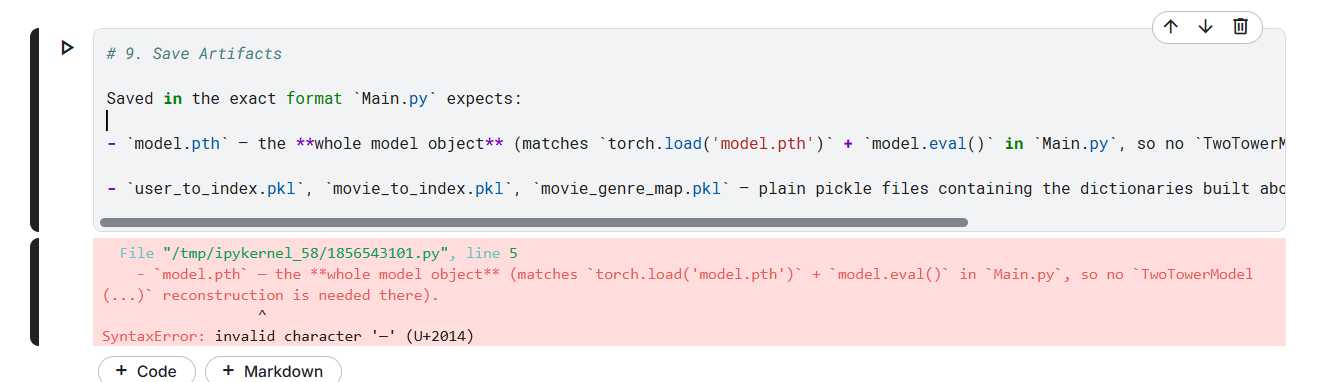

In [ ]:
model = torch.load("/kaggle/input/datasets/daksh59678/testing/model.pth", map_location=cfg.device, weights_only=False)
model.to(cfg.device)
model.eval()

with open("/kaggle/input/datasets/daksh59678/testing/user_to_index.pkl", "rb") as f:
    user_to_index = pickle.load(f)

with open("/kaggle/input/datasets/daksh59678/testing/movie_to_index.pkl", "rb") as f:
    movie_to_index = pickle.load(f)

with open("/kaggle/input/datasets/daksh59678/testing/movie_genre_map.pkl", "rb") as f:
    movie_genre_map = pickle.load(f)
print("Loaded: model.pth, user_to_index.pkl, movie_to_index.pkl, movie_genre_map.pkl")

## 11. Recommendation Function

In [ ]:
def get_recommendations(user_id, model, movie_to_index, user_to_index, movie_genre_map, top_k=5):
    """Generate recommendations for a specific user ID (original ID, not index)."""
    model.eval() 
    if user_id not in user_to_index:
        print("User not found (Cold Start). Returning popular movies instead...")
        popular = ratings_per_movie.sort_values(ascending=False).head(top_k)
        return [(mid, None) for mid in popular.index]

    u_idx = user_to_index[user_id]
    user_tensor = torch.tensor([u_idx]).to(cfg.device)
    with torch.no_grad():
        user_vec = model.forward_user(user_tensor)
    all_movie_indices = list(movie_to_index.values())
    all_genre_indices = [movie_genre_map[i] for i in all_movie_indices]
    movie_tensor = torch.tensor(all_movie_indices).to(cfg.device)
    genre_tensor = torch.tensor(all_genre_indices).to(cfg.device)
    with torch.no_grad():
        movie_vecs = model.forward_movie(movie_tensor, genre_tensor)
        scores = (user_vec * movie_vecs).sum(dim=1)
    top_scores, top_indices = torch.topk(scores, min(top_k, len(scores)))
    index_to_movie = {v: k for k, v in movie_to_index.items()}
    recommendations = []
    for score, idx in zip(top_scores, top_indices):
        movie_id = index_to_movie[idx.item()]
        recommendations.append((movie_id, score.item()))
    return recommendations


## 12. Recommendation Performance Evaluation
The trained model is evaluated using Precision@5, Recall@5, and NDCG@5 with a negative sampling strategy. This evaluation measures how effectively the model ranks relevant movies among a realistic set of candidate movies. 

In [ ]:
"""
Recommendation evaluation with NEGATIVE SAMPLING.

Instead of ranking each user's positive (validation) movies against the
entire catalog (~87k movies), we rank them against a much smaller,
realistic candidate set: the positives + N randomly sampled movies the
user has never interacted with at all (neither in train nor val).

Expected variables already available:
- model
- train_df
- val_df
- movie_to_index
- movie_genre_map
- cfg
"""

import math
import numpy as np
import torch

K = 5
NUM_NEGATIVES = 100
RELEVANCE_THRESHOLD = 4.0
SEED = 42

model.eval()
rng = np.random.default_rng(SEED)

# ---------------- Setup ---------------- #

all_movie_indices = np.array(list(movie_to_index.values()))
all_genre_indices = [movie_genre_map[m] for m in all_movie_indices]

all_movie_tensor = torch.tensor(all_movie_indices, device=cfg.device)
all_genre_tensor = torch.tensor(all_genre_indices, device=cfg.device)

# Precompute the movie tower ONCE for every movie (reused for every user)
with torch.no_grad():
    all_movie_vecs = model.forward_movie(all_movie_tensor, all_genre_tensor)  # [num_movies, out_dim]

# Map movie_idx -> row position in all_movie_vecs / all_movie_indices,
# so we can slice out just the candidates we need per user.
movieidx_to_row = {m: i for i, m in enumerate(all_movie_indices)}

# Every movie a user has interacted with AT ALL (train + val, any rating).
# These are excluded from negative sampling — negatives must be truly "unseen".
interacted_movies = (
    pd.concat([train_df[["user_idx", "movie_idx"]], val_df[["user_idx", "movie_idx"]]])
    .groupby("user_idx")["movie_idx"]
    .apply(set)
    .to_dict()
)

# Positive (relevant) movies per user, from validation set only.
relevant_movies = (
    val_df[val_df["rating"] >= RELEVANCE_THRESHOLD]
    .groupby("user_idx")["movie_idx"]
    .apply(set)
    .to_dict()
)

all_movie_indices_set = set(all_movie_indices.tolist())


def sample_negatives(user_idx, num_negatives=NUM_NEGATIVES):
    """Sample movies the user has never interacted with (train or val)."""
    watched = interacted_movies.get(user_idx, set())
    candidates_pool = np.array(list(all_movie_indices_set - watched))

    if len(candidates_pool) <= num_negatives:
        return candidates_pool  # not enough unseen movies, just use all of them

    return rng.choice(candidates_pool, size=num_negatives, replace=False)


@torch.no_grad()
def recommend_from_candidates(user_idx, candidate_movie_idxs, k=K):
    """Score and rank only the given candidate movies (positives + negatives)."""
    user_tensor = torch.tensor([user_idx], device=cfg.device)
    user_vec = model.forward_user(user_tensor)  # [1, out_dim]

    rows = [movieidx_to_row[m] for m in candidate_movie_idxs]
    candidate_vecs = all_movie_vecs[rows]  # [num_candidates, out_dim]

    scores = (user_vec * candidate_vecs).sum(dim=1).cpu().numpy()

    order = np.argsort(-scores)[:k]
    ranked = [int(candidate_movie_idxs[i]) for i in order]
    return ranked


# ---------------- Metrics (same as before) ---------------- #

def precision_at_k(predicted, relevant, k=5):
    if len(predicted) == 0:
        return 0
    hits = len(set(predicted[:k]) & relevant)
    return hits / k


def recall_at_k(predicted, relevant, k=5):
    if len(relevant) == 0:
        return 0
    hits = len(set(predicted[:k]) & relevant)
    return hits / len(relevant)


def dcg_at_k(predicted, relevant, k=5):
    dcg = 0.0
    for i, movie in enumerate(predicted[:k]):
        if movie in relevant:
            dcg += 1 / math.log2(i + 2)
    return dcg


def ndcg_at_k(predicted, relevant, k=5):
    if len(relevant) == 0:
        return 0
    dcg = dcg_at_k(predicted, relevant, k)
    ideal_hits = min(len(relevant), k)
    idcg = sum(1 / math.log2(i + 2) for i in range(ideal_hits))
    if idcg == 0:
        return 0
    return dcg / idcg


# ---------------- Overall Evaluation (with negative sampling) ---------------- #

def evaluate_model_negative_sampling():
    precisions, recalls, ndcgs = [], [], []
    users_evaluated = 0
    total_users = len(relevant_movies)
    print(f"Starting negative-sampling evaluation over up to {total_users:,} users "
          f"({NUM_NEGATIVES} negatives per user)...")
    for user_idx, relevant in relevant_movies.items():
        if len(relevant) == 0:
            continue
        negatives = sample_negatives(user_idx, NUM_NEGATIVES)
        candidate_movie_idxs = np.concatenate([np.array(list(relevant)), negatives])

        predicted = recommend_from_candidates(user_idx, candidate_movie_idxs, k=K)

        precisions.append(precision_at_k(predicted, relevant, K))
        recalls.append(recall_at_k(predicted, relevant, K))
        ndcgs.append(ndcg_at_k(predicted, relevant, K))
        users_evaluated += 1

        if users_evaluated % 1000 == 0:
            print(f"  ...evaluated {users_evaluated:,}/{total_users:,} users")

    print(f"Finished evaluating {users_evaluated:,} users.")

    return {
        "Precision@5": np.mean(precisions),
        "Recall@5": np.mean(recalls),
        "NDCG@5": np.mean(ndcgs),
        "Users": users_evaluated,
    }


# ---------------- Run ---------------- #

results = evaluate_model_negative_sampling()

print("=" * 55)
print(f"Negative-Sampling Evaluation (1 positive + {NUM_NEGATIVES} negatives)")
print("=" * 55)
print(f"Precision@5       : {results['Precision@5']:.4f}")
print(f"Recall@5          : {results['Recall@5']:.4f}")
print(f"NDCG@5            : {results['NDCG@5']:.4f}")
print(f"Users Evaluated   : {results['Users']:,}")
print("=" * 55)

In [ ]:
if "movie_id_to_title" not in globals():
      movie_id_to_title = dict(zip(df_movies["movieId"], df_movies["title"]))

## 13. 🎬 Interactive: Get Recommendations for a User

Run this cell and enter a user ID when prompted (leave blank to use a random user
from the dataset).

In [ ]:
_input = input("Enter a user ID (or leave blank for a random user): ").strip()

if _input == "":
    query_user_id = int(df_ratings["userId"].sample(1, random_state=None).iloc[0])
    print(f"No ID entered — using random user {query_user_id}")
else:
    query_user_id = int(_input)

recs = get_recommendations(query_user_id, model, movie_to_index, user_to_index, movie_genre_map, top_k=10)

print(f"\nTop recommendations for user {query_user_id}:\n")
rows = []
for movie_id, score in recs:
    title = movie_id_to_title.get(movie_id, f"Movie {movie_id}")
    rows.append({"movieId": movie_id, "title": title, "predicted_score": score})

rec_df = pd.DataFrame(rows)
rec_df


In [ ]:
# --- Visualize the recommendation scores ---
if rec_df["predicted_score"].notna().any():
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(x="predicted_score", y="title", data=rec_df, color="#4C72B0", ax=ax)
    ax.set_title(f"Top Recommendations for User {query_user_id}")
    ax.set_xlabel("Predicted score")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig("fig_user_recommendations.png", dpi=150)
    plt.show()


## 14. "Movies Like This": Enter a Title, Get Similar Movies

This uses cosine similarity between **movie tower embeddings** (title + genres), so you
can type in a movie you like and get similar ones back — independent of any user ID.

In [ ]:
def find_similar_movies(title_query, model, df_movies, movie_to_index, movie_genre_map, top_k=10):
    matches = df_movies[df_movies["title"].str.contains(title_query, case=False, na=False, regex=False)]
    if matches.empty:
        print(f"No movie title matching '{title_query}' found.")
        return None, None

    if len(matches) > 1:
        print(f"Multiple matches found, using the first one: '{matches.iloc[0]['title']}'")
    match_row = matches.iloc[0]
    query_movie_id = match_row["movieId"]
    query_idx = movie_to_index[query_movie_id]

    all_movie_indices = list(movie_to_index.values())
    all_genre_indices = [movie_genre_map[i] for i in all_movie_indices]

    movie_tensor = torch.tensor(all_movie_indices).to(cfg.device)
    genre_tensor = torch.tensor(all_genre_indices).to(cfg.device)

    model.eval()
    with torch.no_grad():
        all_vecs = model.forward_movie(movie_tensor, genre_tensor)
        query_vec = all_vecs[all_movie_indices.index(query_idx)].unsqueeze(0)

        sims = torch.nn.functional.cosine_similarity(query_vec, all_vecs)

    top_scores, top_indices_pos = torch.topk(sims, top_k + 1)  # +1 because the movie itself will match perfectly
    index_to_movie = {v: k for k, v in movie_to_index.items()}

    results = []
    for score, pos in zip(top_scores, top_indices_pos):
        idx = all_movie_indices[pos.item()]
        mid = index_to_movie[idx]
        if mid == query_movie_id:
            continue
        results.append({"movieId": mid, "title": movie_id_to_title.get(mid, str(mid)), "similarity": score.item()})
        if len(results) == top_k:
            break

    return match_row["title"], pd.DataFrame(results)


_title_query = input("Enter a movie title (or part of it): ").strip()
if _title_query:
    matched_title, similar_df = find_similar_movies(_title_query, model, df_movies, movie_to_index, movie_genre_map, top_k=10)
    if similar_df is not None:
        print(f"\nMovies similar to '{matched_title}':\n")
        display(similar_df) 

## 15. Cold Start Recommendation for New Users

This section demonstrates how the system generates personalized recommendations for users with no prior interaction history by using their favorite movies. It also supports registering new users for future recommendations.

In [ ]:
"""
NEW USER SUPPORT — Cold Start Handling
========================================
Two things this adds:

1. recommend_for_new_user()  -> give recommendations to a brand-new user
   who has NO trained embedding yet, by averaging the vectors of a few
   movies they say they like (content-based cold start).

2. register_new_user()       -> permanently add the new user's ID into
   user_to_index and expand the model's user_embedding table so they can
   be treated like a normal user once they've rated enough movies and
   the model gets retrained/fine-tuned.

Expected variables already available from earlier cells:
- model, cfg, movie_to_index, movie_genre_map, user_to_index, df_movies
"""

import torch
import torch.nn as nn
import numpy as np

# ---------------- Safety net: make sure fallback data exists ---------------- #
# (needed for the "popularity fallback" path if liked movies aren't recognized)

if "ratings_per_movie" not in globals():
    index_to_movie = {v: k for k, v in movie_to_index.items()}
    ratings_per_movie = df_ratings.groupby("movie_idx").size().sort_values(ascending=False)
    ratings_per_movie.index = ratings_per_movie.index.map(index_to_movie)

if "movie_id_to_title" not in globals():
    movie_id_to_title = dict(zip(df_movies["movieId"], df_movies["title"]))

if "index_to_movie" not in globals():
    index_to_movie = {v: k for k, v in movie_to_index.items()}


# ---------------- 1. Cold-start recommendations ---------------- #

@torch.no_grad()
def compute_cold_start_vector(liked_movie_ids, model, movie_to_index, movie_genre_map, cfg):
    """
    Build a 'pseudo user vector' for a brand-new user by averaging the
    movie-tower vectors of a few movies they say they like.
    No trained user_embedding row is needed for this.
    """
    liked_indices = [movie_to_index[mid] for mid in liked_movie_ids if mid in movie_to_index]

    if len(liked_indices) == 0:
        return None  # none of the liked movies exist in our catalog

    genre_indices = [movie_genre_map[i] for i in liked_indices]

    movie_tensor = torch.tensor(liked_indices).to(cfg.device)
    genre_tensor = torch.tensor(genre_indices).to(cfg.device)

    liked_vecs = model.forward_movie(movie_tensor, genre_tensor)   # [num_liked, out_dim]
    pseudo_user_vector = liked_vecs.mean(dim=0, keepdim=True)      # [1, out_dim] <- average

    return pseudo_user_vector


@torch.no_grad()
def recommend_for_new_user(liked_movie_ids, model, movie_to_index, movie_genre_map, cfg, top_k=5):
    """Cold-start recommendations for a user with NO trained embedding yet."""
    model.eval()

    pseudo_user_vector = compute_cold_start_vector(
        liked_movie_ids, model, movie_to_index, movie_genre_map, cfg
    )

    if pseudo_user_vector is None:
        print("None of the liked movies were recognized. Falling back to popularity...")
        popular = ratings_per_movie.sort_values(ascending=False).head(top_k)
        return [(mid, None) for mid in popular.index]

    all_movie_indices = list(movie_to_index.values())
    all_genre_indices = [movie_genre_map[i] for i in all_movie_indices]

    movie_tensor = torch.tensor(all_movie_indices).to(cfg.device)
    genre_tensor = torch.tensor(all_genre_indices).to(cfg.device)

    all_movie_vecs = model.forward_movie(movie_tensor, genre_tensor)
    scores = (pseudo_user_vector * all_movie_vecs).sum(dim=1)

    liked_set = set(liked_movie_ids)
    idx_to_movie = {v: k for k, v in movie_to_index.items()}

    top_scores, top_indices = torch.topk(scores, min(top_k + len(liked_movie_ids), len(scores)))

    recommendations = []
    for score, idx in zip(top_scores, top_indices):
        movie_id = idx_to_movie[idx.item()]
        if movie_id in liked_set:
            continue
        recommendations.append((movie_id, score.item()))
        if len(recommendations) == top_k:
            break

    return recommendations


# ---------------- 2. Registering a new user permanently ---------------- #

def register_new_user(new_user_id, user_to_index, model, cfg):
    """
    Adds a new user_id to the mapping and expands the model's
    user_embedding table by one row to make room for them.
    NOTE: the new row is randomly initialized (untrained) — it only
    becomes meaningful once you retrain/fine-tune on their real ratings.
    """
    if new_user_id in user_to_index:
        print(f"User {new_user_id} already exists at index {user_to_index[new_user_id]}.")
        return user_to_index[new_user_id]

    new_idx = len(user_to_index)
    user_to_index[new_user_id] = new_idx

    old_weight = model.user_embedding.weight.data
    new_embedding = nn.Embedding(old_weight.shape[0] + 1, old_weight.shape[1]).to(cfg.device)
    new_embedding.weight.data[:-1] = old_weight                    # keep old rows unchanged
    nn.init.normal_(new_embedding.weight.data[-1:], std=0.01)      # small random init for new row

    model.user_embedding = new_embedding
    print(f"Registered new user {new_user_id} at index {new_idx}. Embedding table expanded to {new_idx + 1} users.")
    return new_idx


# ---------------- Interactive: try it out ---------------- #

print("=" * 60)
print("NEW USER ONBOARDING (Cold Start)")
print("=" * 60)

_titles_input = input(
    "Enter a few movie titles you like, separated by commas "
    "(e.g. 'Toy Story, Jumanji'): "
).strip()

if _titles_input:
    typed_titles = [t.strip() for t in _titles_input.split(",") if t.strip()]

    matched_ids = []
    for t in typed_titles:
        match = df_movies[df_movies["title"].str.contains(t, case=False, na=False, regex=False)]
        if not match.empty:
            mid = match.iloc[0]["movieId"]
            matched_ids.append(mid)
            print(f"  Matched '{t}' -> {match.iloc[0]['title']} (movieId={mid})")
        else:
            print(f"  No match found for '{t}', skipping.")

    if matched_ids:
        recs = recommend_for_new_user(
            matched_ids, model, movie_to_index, movie_genre_map, cfg, top_k=10
        )

        print("\nCold-start recommendations based on what you like:\n")
        rows = []
        for movie_id, score in recs:
            title = movie_id_to_title.get(movie_id, f"Movie {movie_id}")
            rows.append({"movieId": movie_id, "title": title, "predicted_score": score})
        new_user_recs_df = pd.DataFrame(rows)
        display(new_user_recs_df)

        # Optionally register them as a permanent user (uncomment to use)
        # new_user_id = 999999999   # pick a real, unused ID from your system
        # register_new_user(new_user_id, user_to_index, model, cfg)
    else:
        print("No movies matched — can't build a cold-start profile. Try different titles.")
else:
    print("No input given, skipping cold-start demo.")